# Preprocess recipes for embedding

Turns the raw Food.com data into a clean, embeddable table. From the dataset
exploration we decided **1 recipe = 1 chunk**: each recipe becomes a single text
document (name + description + ingredients + instructions), well within an 8k-token
embedding context.

**Reviews** are used as a recomputed **quality signal** (count-weighted rating + review
count) attached to each recipe as metadata for filtering/re-ranking at retrieval time —
not embedded as separate documents.

Pipeline: **load → clean → build doc → dedup → reviews signal → (optional) sample → save**.

Set `SAMPLE_SIZE` to a small number while developing, then `None` for the full
~520k-recipe run (≈118M tokens, ≈\$2.4 on `text-embedding-3-small`).

### Config

In [2]:
from pathlib import Path

SAMPLE_SIZE = 5_000          # set to None to keep the full dataset
SEED = 42
PRIOR_STRENGTH = 10          # Bayesian shrinkage: ~how many "average" reviews to assume
OUT_DIR = Path("../.data")   # repo root (notebook runs from notebooks/)
OUT_PATH = OUT_DIR / ("recipes_sample.parquet" if SAMPLE_SIZE else "recipes_clean.parquet")

### Load

In [3]:
import kagglehub
import pandas as pd
import numpy as np

path = Path(kagglehub.dataset_download("irkaal/foodcom-recipes-and-reviews"))
recipes = pd.read_parquet(path / "recipes.parquet")
reviews = pd.read_parquet(path / "reviews.parquet")
print(f"raw recipes: {len(recipes):,}  |  raw reviews: {len(reviews):,}")

/Users/nico/serenis-health/ai-bootcamp/ragu/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


raw recipes: 522,517  |  raw reviews: 1,401,982


### Clean

Drop rows that can't produce a useful embedding document: missing name or instructions.
Everything else (nutrition, ratings, etc.) is kept as metadata.

In [4]:
def join_arr(x):
    """Flatten an array-valued cell (ingredients / instructions) into one string."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return " ".join(str(s) for s in x if s is not None)
    return "" if x is None else str(x)


df = recipes.copy()
df["Name"] = df["Name"].fillna("").astype(str).str.strip()
df["Description"] = df["Description"].fillna("").astype(str).str.strip()
df["ingredients_text"] = df["RecipeIngredientParts"].map(join_arr).str.strip()
df["instructions_text"] = df["RecipeInstructions"].map(join_arr).str.strip()

before = len(df)
df = df[(df["Name"] != "") & (df["instructions_text"] != "")]
print(f"dropped {before - len(df):,} rows missing name/instructions")
print(f"clean recipes: {len(df):,}")

dropped 3 rows missing name/instructions
clean recipes: 522,514


### Build the embedding document

One document per recipe. A light field-labelled template helps the embedding model
(and later, the LLM reading retrieved context) tell the parts apart.

In [5]:
def build_doc(row):
    parts = [row["Name"]]
    if row["Description"]:
        parts.append(row["Description"])
    if row["ingredients_text"]:
        parts.append("Ingredients: " + row["ingredients_text"])
    parts.append("Instructions: " + row["instructions_text"])
    return "\n".join(parts)


df["text"] = df.apply(build_doc, axis=1)
print(df["text"].iloc[0])

Low-Fat Berry Blue Frozen Dessert
Make and share this Low-Fat Berry Blue Frozen Dessert recipe from Food.com.
Ingredients: blueberries granulated sugar vanilla yogurt lemon juice
Instructions: Toss 2 cups berries with sugar. Let stand for 45 minutes, stirring occasionally. Transfer berry-sugar mixture to food processor. Add yogurt and process until smooth. Strain through fine sieve. Pour into baking pan (or transfer to ice cream maker and process according to manufacturers' directions). Freeze uncovered until edges are solid but centre is soft.  Transfer to processor and blend until smooth again. Return to pan and freeze until edges are solid. Transfer to processor and blend until smooth again. Fold in remaining 2 cups of blueberries. Pour into plastic mold and freeze overnight. Let soften slightly to serve.


### Deduplicate

Recipe *names* repeat (legit variants), so we don't dedup on name. We drop only exact
duplicate documents, which are true repeats that would skew retrieval.

In [6]:
before = len(df)
df = df.drop_duplicates(subset="text")
print(f"dropped {before - len(df):,} exact-duplicate documents")
print(f"unique recipes: {len(df):,}")

dropped 535 exact-duplicate documents
unique recipes: 521,979


### Reviews → quality signal

The dataset's precomputed `AggregatedRating` only matches a fresh recompute ~66% of the
time, so we recompute from the reviews table. Notes:

- **0-star reviews mean "commented without rating"** — excluded from the rating mean, but
  still counted as engagement (`review_count`).
- Ratings are heavily skewed to 5, and a single 5-star review shouldn't outrank a recipe
  with hundreds of reviews. We use a **count-weighted (Bayesian) rating** that shrinks
  low-volume recipes toward the global mean:

  `bayes = (v·R + m·C) / (v + m)`  where *R* = recipe mean, *v* = #ratings,
  *C* = global mean, *m* = `PRIOR_STRENGTH`.

Recipes with no ratings get `bayes = C` (treated as "average / unknown").

In [7]:
rated = reviews[reviews["Rating"] > 0]
global_mean = rated["Rating"].mean()

agg = reviews.groupby("RecipeId").agg(
    review_count=("ReviewId", "size"),
    n_ratings=("Rating", lambda s: (s > 0).sum()),
    mean_rating=("Rating", lambda s: s[s > 0].mean()),
)
agg["bayesian_rating"] = (
    (agg["n_ratings"] * agg["mean_rating"].fillna(global_mean) + PRIOR_STRENGTH * global_mean)
    / (agg["n_ratings"] + PRIOR_STRENGTH)
)

df = df.merge(agg, left_on="RecipeId", right_index=True, how="left")
df["review_count"] = df["review_count"].fillna(0).astype(int)
df["n_ratings"] = df["n_ratings"].fillna(0).astype(int)
df["bayesian_rating"] = df["bayesian_rating"].fillna(global_mean)
df["has_reviews"] = df["review_count"] > 0

print(f"global mean rating (excl. 0-star): {global_mean:.3f}")
print(f"recipes with >=1 review: {df['has_reviews'].mean():.1%}")
print(df[["mean_rating", "bayesian_rating", "review_count"]].describe().round(2))

global mean rating (excl. 0-star): 4.661
recipes with >=1 review: 52.0%
       mean_rating  bayesian_rating  review_count
count    265751.00        521979.00     521979.00
mean          4.58             4.66          2.69
std           0.63             0.08         14.45
min           1.00             3.14          0.00
25%           4.33             4.66          0.00
50%           4.88             4.66          1.00
75%           5.00             4.69          2.00
max           5.00             4.98       2892.00


### Stratified sample (dev only)

When `SAMPLE_SIZE` is set, take a sample stratified by category and whether the recipe
has reviews, so the dev set mirrors the full distribution instead of over-representing
the dominant categories. With `SAMPLE_SIZE = None` the full dataset passes through.

In [8]:
df["RecipeCategory"] = df["RecipeCategory"].fillna("Unknown")

if SAMPLE_SIZE and SAMPLE_SIZE < len(df):
    frac = SAMPLE_SIZE / len(df)
    sampled = df.groupby(
        ["RecipeCategory", "has_reviews"], observed=True
    ).sample(frac=frac, random_state=SEED)
    df_out = sampled.sample(n=min(SAMPLE_SIZE, len(sampled)), random_state=SEED)
    print(f"stratified sample: {len(df_out):,} of {len(df):,}")
else:
    df_out = df
    print(f"full dataset: {len(df_out):,}")

stratified sample: 4,983 of 521,979


### Check the sample mirrors the full dataset

`RecipeCategory` and `has_reviews` match the full set **by construction** (we stratified
on them). The real question is whether the variables we *didn't* stratify on survived the
sampling. We plot them as **densities** (area = 1) so the small sample and the full set
overlap despite the ~100x size gap — if the shapes line up, the sample is representative.

has_reviews share   full: 52.0%   sample: 52.0%


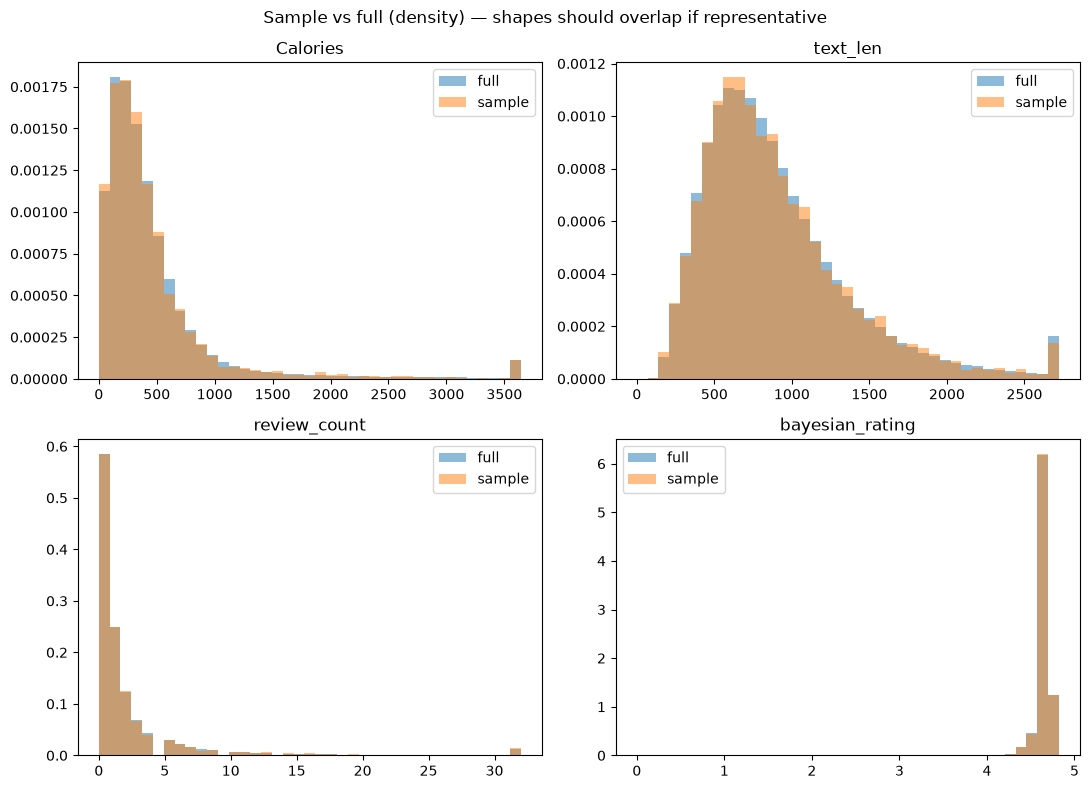

In [9]:
import matplotlib.pyplot as plt

df_out = df_out.copy()
df["text_len"] = df["text"].str.len()
df_out["text_len"] = df_out["text"].str.len()

check_cols = ["Calories", "text_len", "review_count", "bayesian_rating"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, ax in zip(check_cols, axes.flat):
    hi = df[col].quantile(0.99)
    bins = np.linspace(0, hi, 40)
    ax.hist(df[col].clip(upper=hi), bins=bins, density=True, alpha=0.5, label="full")
    ax.hist(df_out[col].clip(upper=hi), bins=bins, density=True, alpha=0.5, label="sample")
    ax.set_title(col)
    ax.legend()

fig.suptitle("Sample vs full (density) — shapes should overlap if representative")
fig.tight_layout()

print(f"has_reviews share   full: {df['has_reviews'].mean():.1%}   sample: {df_out['has_reviews'].mean():.1%}")

### Save

In [10]:
keep = [
    "RecipeId", "Name", "RecipeCategory", "Keywords",
    "review_count", "n_ratings", "mean_rating", "bayesian_rating", "has_reviews",
    "text",
]
out = df_out[keep].reset_index(drop=True)

OUT_DIR.mkdir(parents=True, exist_ok=True)
out.to_parquet(OUT_PATH, index=False)

tok = out["text"].str.len().sum() / 4  # rough ~chars/4 token estimate
print(f"wrote {len(out):,} recipes -> {OUT_PATH}")
print(f"~{tok / 1e6:.1f}M tokens  (~${tok / 1e6 * 0.02:.2f} on text-embedding-3-small)")
out.head()

wrote 4,983 recipes -> .data/recipes_sample.parquet
~1.1M tokens  (~$0.02 on text-embedding-3-small)


,RecipeId,Name,RecipeCategory,Keywords,review_count,n_ratings,mean_rating,bayesian_rating,has_reviews,text
0,336672.0,Lindzee's Fruit Dip,Fruit,"[Brunch, < 15 Mins, Easy]",0,0,NaN,4.661469,False,Lindzee's Fruit Dip\nGot this recipe from a fr...
1,521201.0,Pheasant Wild Rice Casserole,< 4 Hours,[None],0,0,NaN,4.661469,False,Pheasant Wild Rice Casserole\nThis recipe work...
2,348540.0,Fresh Tomato Pie,Savory Pies,"[Lunch/Snacks, < 30 Mins, Beginner Cook, Easy,...",0,0,NaN,4.661469,False,"Fresh Tomato Pie\nI have not tried this yet, b..."
3,398948.0,Seafood &amp; Vegetable Chowder,Chowders,"[Vegetable, Weeknight, < 4 Hours]",0,0,NaN,4.661469,False,Seafood &amp; Vegetable Chowder\nMake and shar...
4,428606.0,Baked Sweet Potatoes With Apricots and Prunes,Yam/Sweet Potato,"[Potato, Vegetable, Southwest Asia (middle Eas...",5,5,5.0,4.774313,True,Baked Sweet Potatoes With Apricots and Prunes\...
